# Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import torch
from typing import Iterator
from torch import nn
from torchvision.models import resnet50, ResNet50_Weights


torch.set_default_device('cuda' if torch.cuda.is_available() else 'cpu')


# DATASET_DIR = '/content/drive/MyDrive/DL/Datasets/  '

DATASET_DIR = '/content/drive/MyDrive/tvsum_dataset'


# Data Loader

In [ ]:
class DataLoader:
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.data_dir = os.path.join(root_dir, "data")
        self.video_dir = os.path.join(root_dir, "video")

        self.anno_file = os.path.join(self.data_dir, "ydata-tvsum50-anno.tsv")
        self.info_file = os.path.join(self.data_dir, "ydata-tvsum50-info.tsv")

        self.info_df = pd.read_csv(self.info_file, sep="\t")
        self.anno_df = pd.read_csv(self.anno_file, sep="\t", names=['video_id', 'category', 'importance_scores'])

        self.video_names = self.info_df["video_id"].tolist()
        self.annotations = self._parse_annotations()

    def _parse_annotations(self):
        annotations = {}

        for video_id in self.video_names:
            video_rows = self.anno_df[self.anno_df["video_id"] == video_id]

            # Each row corresponds to one user
            user_scores = []
            for _, row in video_rows.iterrows():
                scores = np.array(
                    list(map(int, row["importance_scores"].split(","))),
                    dtype=np.float32
                )
                user_scores.append(scores)

            annotations[video_id] = np.stack(user_scores, axis=0)

        return annotations

    def get_video_annotation(self, video_id):
        return self.annotations[video_id]

    def get_video_frames(self, video_id: str, batch_size=32) -> Iterator[torch.Tensor]:
        video_path = os.path.join(self.video_dir, f"{video_id}.mp4")
        cap = cv2.VideoCapture(video_path)

        finished = False
        try:
            while not finished:
                frames = []

                for i in range(batch_size):
                    ret, frame = cap.read()
                    if not ret:
                        finished = True
                        break

                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) # BGR → RGB
                    frame = torch.from_numpy(frame).permute(2, 0, 1) # HWC → CHW
                    frames.append(frame)

                if len(frames) > 0:
                    yield torch.stack(frames)
        finally:
            cap.release()

# Feature Extractor

In [ ]:
from abc import ABC, abstractmethod

class FeatureExtractor(nn.Module, ABC):
    def __init__(self):
        super().__init__()

    @abstractmethod
    def preprocess(self, img:torch.Tensor) -> torch.Tensor:
        pass

    @abstractmethod
    def extract_features(self, img:torch.Tensor) -> torch.Tensor:
        pass


class ResNetFeatureExtractor(FeatureExtractor):
    def __init__(self):
        super().__init__()
        self.weights = ResNet50_Weights.IMAGENET1K_V2
        self.resnet = resnet50(weights=self.weights)
        self.resnet.fc = nn.Identity() # remove final FC layer
        self.resnet.eval()

    def preprocess(self, img:torch.Tensor) -> torch.Tensor:
        img = img.to(self.resnet.conv1.weight.device)
        return self.weights.transforms()(img)

    def extract_features(self, img:torch.Tensor) -> torch.Tensor:
        return self.resnet(img)

    def train(self, mode=True):
        super().train(mode)
        self.resnet.eval()
        return self


# KMeans Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.utils.random import sample_without_replacement

class VideoSummarizer:
    def __init__(self, data_loader, feature_extractor):
        self.data_loader = data_loader
        self.feature_extractor = feature_extractor
        self.all_features = None
        self.final_labels = None
        self.final_kmeans = None

    def summarize(self, video_id):
        # exctracting features from frames
        features_list = []
        for batch in self.data_loader.get_video_frames(video_id, batch_size=32):
            batch = self.feature_extractor.preprocess(batch)

            with torch.no_grad():
                features = self.feature_extractor.extract_features(batch)

            features_list.append(features.cpu().numpy())

        all_features = np.concatenate(features_list, axis=0)
        self.all_features = all_features

        #  Cluster them
        k_range = range(5, min(21, len(all_features) // 10))
        sample_size = min(1000, len(all_features))
        sample_indices = sample_without_replacement(len(all_features), sample_size, random_state=42)
        sample_features = all_features[sample_indices]

        best_score = -1
        best_k = None
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42)
            labels = kmeans.fit_predict(sample_features)
            score = silhouette_score(sample_features, labels)

            if score > best_score:
                best_score = score
                best_k = k

        final_kmeans = KMeans(n_clusters=best_k, random_state=42)
        final_labels = final_kmeans.fit_predict(all_features)
        self.final_labels = final_labels
        self.final_kmeans = final_kmeans


        representative_indices = []
        for cluster_id in range(best_k):
            centroid = final_kmeans.cluster_centers_[cluster_id]
            cluster_indices = np.where(final_labels == cluster_id)[0]
            cluster_features = all_features[cluster_indices]

            distances = np.linalg.norm(cluster_features - centroid, axis=1)

            closest_idx = np.argmin(distances) # select mearest one to the centroid
            representative_index = cluster_indices[closest_idx]

            representative_indices.append(representative_index)

        return representative_indices

### Final Example

In [ ]:
loader = DataLoader(DATASET_DIR)
features_extractor = ResNetFeatureExtractor()
summarizer = VideoSummarizer(loader, features_extractor)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]


In [ ]:
key_frames_indices = summarizer.summarize('AwmHb44_ouw')

In [ ]:
# Get the actual frames
cap = cv2.VideoCapture(f'{DATASET_DIR}/video/AwmHb44_ouw.mp4')
frames_to_show = []

for idx in sorted(key_frames_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        frames_to_show.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

cap.release()

In [ ]:
print(len(key_frames_indices))
print(len(frames_to_show))
print(len(summarizer.all_features))

13
13
10597


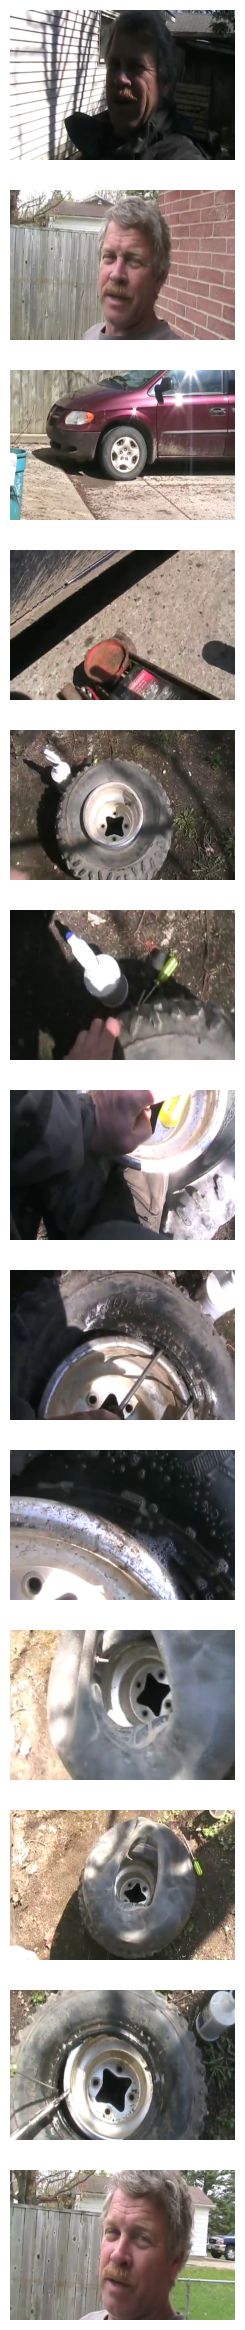

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(frames_to_show), 1, figsize=(50, 30))
for ax, frame in zip(axes.flat, frames_to_show):
    ax.imshow(frame)
    ax.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def visualize_clusters(all_features, final_labels, final_kmeans, representative_indices):

    n_samples = len(all_features)
    n_clusters = len(np.unique(final_labels))

    if n_samples < 30:
        perplexity = max(5, n_samples // 3)
    else:
        perplexity = 30

    print(f"Visualizing {n_samples} frames in {n_clusters} clusters")
    print(f"Using perplexity={perplexity}")
    print("Reducing dimensionality with t-SNE (this may take a minute)...")

    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=1000)
    features_2d = tsne.fit_transform(all_features)

    centroids_2d = np.array([
        features_2d[final_labels == cluster_id].mean(axis=0)
        for cluster_id in range(n_clusters)
    ])

    plt.figure(figsize=(12, 8))
    n_clusters = len(np.unique(final_labels))
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    for cluster_id in range(n_clusters):
        cluster_mask = final_labels == cluster_id
        cluster_points = features_2d[cluster_mask]

        plt.scatter(
            cluster_points[:, 0],
            cluster_points[:, 1],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id}',
            alpha=0.6,
            s=50
        )

        plt.scatter(
            centroids_2d[cluster_id, 0],
            centroids_2d[cluster_id, 1],
            c=[colors[cluster_id]],
            marker='X',
            s=500,
            edgecolors='black',
            linewidths=2,
            label=f'Centroid {cluster_id}'
        )

    rep_points = features_2d[representative_indices]
    plt.scatter(
        rep_points[:, 0],
        rep_points[:, 1],
        c='red',
        marker='*',
        s=800,
        edgecolors='black',
        linewidths=2,
        label='Representatives',
        zorder=5
    )

    plt.title(f'Video Frame Clusters (K={n_clusters})', fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def visualize_clusters_fast(all_features, final_labels, final_kmeans, representative_indices):
    print("Reducing dimensionality with PCA (fast)...")
    pca = PCA(n_components=2, random_state=42)
    features_2d = pca.fit_transform(all_features)
    centroids_2d = pca.transform(final_kmeans.cluster_centers_)

    plt.figure(figsize=(12, 8))
    n_clusters = len(np.unique(final_labels))
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    for cluster_id in range(n_clusters):
        cluster_mask = final_labels == cluster_id
        cluster_points = features_2d[cluster_mask]

        plt.scatter(
            cluster_points[:, 0],
            cluster_points[:, 1],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id}',
            alpha=0.6,
            s=50
        )

        plt.scatter(
            centroids_2d[cluster_id, 0],
            centroids_2d[cluster_id, 1],
            c=[colors[cluster_id]],
            marker='X',
            s=500,
            edgecolors='black',
            linewidths=2
        )

    rep_points = features_2d[representative_indices]
    plt.scatter(
        rep_points[:, 0],
        rep_points[:, 1],
        c='red',
        marker='*',
        s=800,
        edgecolors='black',
        linewidths=2,
        label='Representatives',
        zorder=5
    )

    plt.title(f'Video Frame Clusters - PCA (K={n_clusters})', fontsize=16, fontweight='bold')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Reducing dimensionality with PCA (fast)...


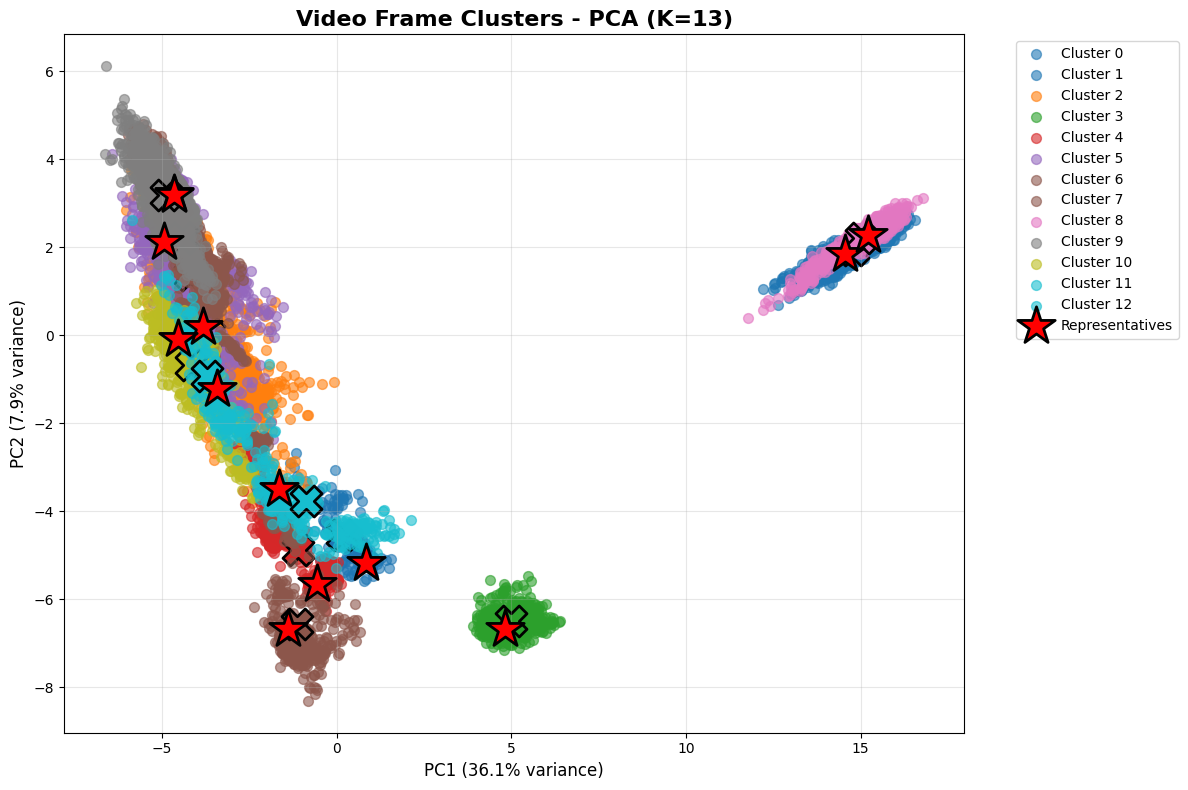

In [ ]:
visualize_clusters_fast(
    all_features=summarizer.all_features,
    final_labels=summarizer.final_labels,
    final_kmeans=summarizer.final_kmeans,
    representative_indices=key_frames_indices
)

Visualizing 10597 frames in 13 clusters
Using perplexity=30
Reducing dimensionality with t-SNE (this may take a minute)...


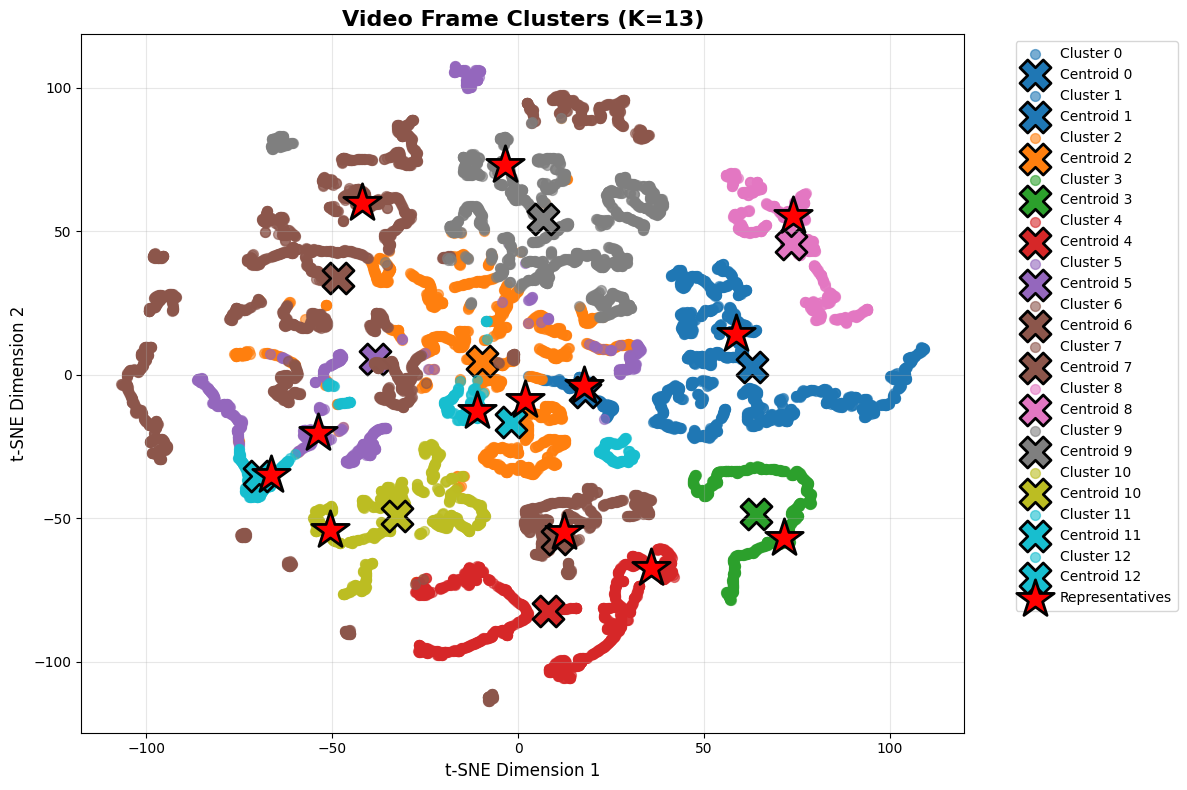

In [ ]:
visualize_clusters(
    all_features=summarizer.all_features,
    final_labels=summarizer.final_labels,
    final_kmeans=summarizer.final_kmeans,
    representative_indices=key_frames_indices
)

# LSTM Autoencoder + KMeans clustring

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
class LSTM_Autoencoder(nn.Module):
    def __init__(self, input_dim=2048, hidden_dim=256, num_layers=1):
        super(LSTM_Autoencoder, self).__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)

        self.decoder = nn.LSTM(hidden_dim * 2, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.output_layer = nn.Linear(hidden_dim * 2, input_dim)

    def forward(self, x):
        # encode
        enc_out, (hn, cn) = self.encoder(x)
        # decode
        dec_out, _ = self.decoder(enc_out)
        # reconstruct
        reconstruction = self.output_layer(dec_out)
        return reconstruction, enc_out

In [ ]:
class VideoSummarizer:
    def __init__(self, feature_extractor):
        self.feature_extractor = feature_extractor
        self.lstm_model = None
        self.all_features = None
        self.final_labels = None
        self.final_kmeans = None

    def _train_lstm(self, features_tensor, epochs=40):
        device = features_tensor.device
        model = LSTM_Autoencoder(input_dim=2048).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.MSELoss()

        model.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            recon, _ = model(features_tensor)
            loss = criterion(recon, features_tensor)
            loss.backward()
            optimizer.step()

        self.lstm_model = model

    def summarize(self, video_path, num_frames=5):
        cap = cv2.VideoCapture(video_path)
        frames = []
        batch_accum = []
        features_list = []

        while True:
            ret, frame = cap.read()
            if not ret: break

            # prepare frame
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)

            # preprocess using  FeatureExtractor
            frame_tensor = torch.from_numpy(frame_rgb).permute(2, 0, 1)
            batch_accum.append(self.feature_extractor.preprocess(frame_tensor))

            # batch Extract
            if len(batch_accum) == 32:
                batch_t = torch.stack(batch_accum)
                with torch.no_grad():
                    feat = self.feature_extractor.extract_features(batch_t)
                features_list.append(feat)
                batch_accum = []

        # Cleanup leftovers
        if batch_accum:
            batch_t = torch.stack(batch_accum)
            with torch.no_grad():
                feat = self.feature_extractor.extract_features(batch_t)
            features_list.append(feat)
        cap.release()

        # combine features: (1, Seq_Len, 2048)
        all_features_tensor = torch.cat(features_list).unsqueeze(0)

        self._train_lstm(all_features_tensor)
        self.lstm_model.eval()
        with torch.no_grad():
            _, latent_out = self.lstm_model(all_features_tensor)

        # clustring
        lstm_features_np = latent_out.squeeze(0).cpu().numpy()
        self.all_features = lstm_features_np

        # K selection
        sample_feat = lstm_features_np
        if len(sample_feat) > 1000:
             idx = sample_without_replacement(len(sample_feat), 1000)
             sample_feat = sample_feat[idx]

        best_score = -1
        best_k = num_frames

        for k in range(num_frames, min(15, len(lstm_features_np)//10)):
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = km.fit_predict(sample_feat)
            try:
                score = silhouette_score(sample_feat, labels)
                if score > best_score:
                    best_score = score
                    best_k = k
            except: pass

        print(f"   > Optimal Clusters: {best_k}")

        # final Clustering
        final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        final_labels = final_kmeans.fit_predict(lstm_features_np)
        self.final_labels = final_labels
        self.final_kmeans = final_kmeans

        # select best
        key_indices = []
        for i in range(best_k):
            centroid = final_kmeans.cluster_centers_[i]
            cluster_idxs = np.where(final_labels == i)[0]
            cluster_feats = lstm_features_np[cluster_idxs]
            dist = np.linalg.norm(cluster_feats - centroid, axis=1)
            key_indices.append(cluster_idxs[np.argmin(dist)])

        return sorted(key_indices), frames

   > Optimal Clusters: 6


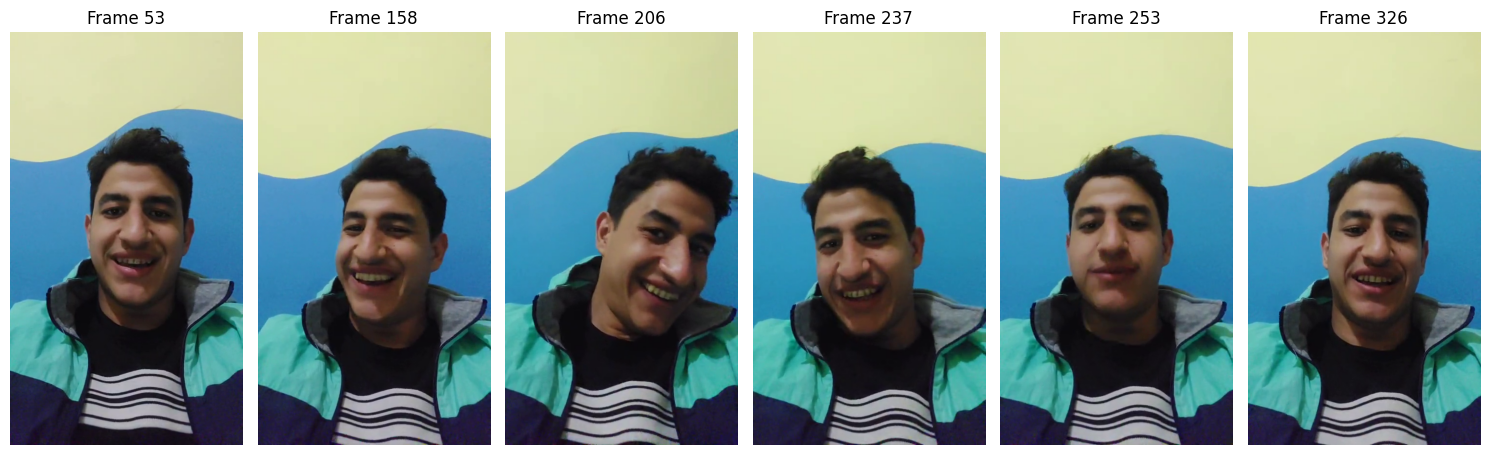

In [ ]:
video_path = "/content/WhatsApp Video 2025-12-18 at 10.46.27 PM.mp4"
if not os.path.exists(video_path):
    print("Downloading sample video...")
    os.system(f"wget -O {video_path} https://www.w3schools.com/html/mov_bbb.mp4")


feature_extractor = ResNetFeatureExtractor()
summarizer = VideoSummarizer(feature_extractor)

key_indices, all_frames = summarizer.summarize(video_path, num_frames=6)


plt.figure(figsize=(15, 5))
for i, idx in enumerate(key_indices):
    plt.subplot(1, len(key_indices), i+1)
    plt.imshow(all_frames[idx])
    plt.axis('off')
    plt.title(f"Frame {idx}")
plt.tight_layout()
plt.show()



# Supervised LSTM using Annotations

In [ ]:
class BiLSTM_Model(nn.Module):
    def __init__(self, input_dim=2048, hidden_dim=256, num_layers=2):
        super(BiLSTM_Model, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=0.5
        )

        self.fc = nn.Sequential( # to predict
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        self.lstm.flatten_parameters()
        lstm_out, _ = self.lstm(x)
        scores = self.fc(lstm_out)
        return scores.squeeze(-1)

In [ ]:
class SupervisedSummarizer:
    def __init__(self, data_loader, feature_extractor):
        self.loader = data_loader
        self.extractor = feature_extractor
        self.model = BiLSTM_Model().cuda()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-4)
        self.criterion = nn.MSELoss()

        self.feature_cache = {}
        self.score_cache = {}

    def precompute_features(self):
        video_ids = self.loader.video_names
        for i, vid_id in enumerate(video_ids):
            try:

                frames_iter = self.loader.get_video_frames(vid_id, batch_size=32)
                features = []
                for batch in frames_iter:
                    batch = self.extractor.preprocess(batch)
                    with torch.no_grad():
                        feat = self.extractor.extract_features(batch)
                    features.append(feat.cpu()) # store on CPU to save GPU VRAM

                if not features: continue
                video_tensor = torch.cat(features)
                self.feature_cache[vid_id] = video_tensor
                raw_anno = self.loader.get_video_annotation(vid_id)
                avg_scores = np.mean(raw_anno, axis=0)
                avg_scores = (avg_scores - avg_scores.min()) / (avg_scores.max() - avg_scores.min() + 1e-6)

                if len(avg_scores) != len(video_tensor):
                    import scipy.ndimage
                    zoom_factor = len(video_tensor) / len(avg_scores)
                    avg_scores = scipy.ndimage.zoom(avg_scores, zoom_factor)

                self.score_cache[vid_id] = torch.tensor(avg_scores, dtype=torch.float32)

                if i % 5 == 0:
                    print(f"   Processed {i}/{len(video_ids)} videos")

            except Exception as e:
                print(f"   Error processing {vid_id}: {e}")
                continue


    def train_on_dataset(self, epochs=20):
        if not self.feature_cache:
            self.precompute_features()

        print(f"\nStarting Supervised Training for {epochs} epochs...")
        self.model.train()

        for epoch in range(epochs):
            epoch_loss = 0
            count = 0

            for vid_id in self.feature_cache:
                features = self.feature_cache[vid_id].cuda().unsqueeze(0)
                targets = self.score_cache[vid_id].cuda().unsqueeze(0)

                self.optimizer.zero_grad()
                predictions = self.model(features)

                loss = self.criterion(predictions, targets)
                loss.backward()
                self.optimizer.step()

                epoch_loss += loss.item()
                count += 1

            print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/count:.5f}")

    def summarize(self, video_id, num_frames=5):
        self.model.eval()
        if video_id in self.feature_cache:
            video_features = self.feature_cache[video_id].cuda().unsqueeze(0)
        else:
            frames_iter = self.loader.get_video_frames(video_id, batch_size=32)
            features = []
            for batch in frames_iter:
                batch = self.extractor.preprocess(batch)
                with torch.no_grad():
                    feat = self.extractor.extract_features(batch)
                features.append(feat)
            video_features = torch.cat(features).unsqueeze(0)

        with torch.no_grad():
            scores = self.model(video_features).squeeze().cpu().numpy()

        top_indices = np.argsort(scores)[::-1]
        selected_indices = []
        min_distance = 15
        for idx in top_indices:
            if len(selected_indices) >= num_frames: break
            if all(abs(idx - s) > min_distance for s in selected_indices):
                selected_indices.append(idx)

        return sorted(selected_indices)

In [ ]:
loader = DataLoader(DATASET_DIR)
features_extractor = ResNetFeatureExtractor()

In [ ]:
supervised_summ = SupervisedSummarizer(loader, features_extractor)

In [ ]:
supervised_summ.train_on_dataset(epochs=5)

   Processed 0/50 videos
   Processed 5/50 videos
   Processed 10/50 videos
   Processed 15/50 videos
   Processed 20/50 videos
   Processed 25/50 videos
   Processed 30/50 videos
   Processed 35/50 videos
   Processed 40/50 videos
   Processed 45/50 videos

Starting Supervised Training for 5 epochs...
Epoch 1/5 | Loss: 0.05960
Epoch 2/5 | Loss: 0.04373
Epoch 3/5 | Loss: 0.03636
Epoch 4/5 | Loss: 0.03111
Epoch 5/5 | Loss: 0.02703


In [ ]:
test_video_id = 'AwmHb44_ouw'
key_frames_indices = supervised_summ.summarize(test_video_id, num_frames=13)
print(f"Selected Indices: {key_frames_indices}")

Selected Indices: [np.int64(2870), np.int64(3201), np.int64(3222), np.int64(3244), np.int64(3771), np.int64(4255), np.int64(4273), np.int64(4289), np.int64(4347), np.int64(4939), np.int64(5838), np.int64(5854), np.int64(5874)]


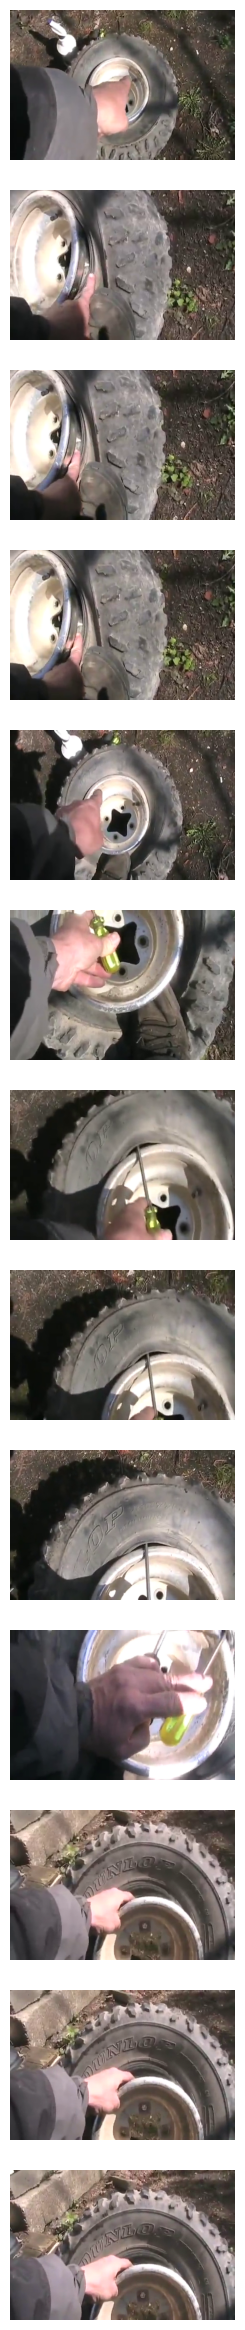

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(frames_to_show), 1, figsize=(50, 30))
for ax, frame in zip(axes.flat, frames_to_show):
    ax.imshow(frame)
    ax.axis('off')
plt.show()